In [1]:
# ============================================================
# GROKKING EXPERIMENT — TRANSFORMER ONLY (Mac MPS)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import pandas as pd
import time

# ============================================================
# Global Configuration
# ============================================================

P = 97
TRAIN_FRACTION = 0.2
STEPS = 600_000
LOG_EVERY = 2000
SEEDS = 5
WIDTH = 512
DEPTH = 1
HEADS = 4

# Mac MPS device setup
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Using device:", DEVICE)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.random.manual_seed(seed)

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p: int, train_fraction: float, seed: int):
    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)
    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):
        x = torch.tensor(data, dtype=torch.long, device=DEVICE)
        y = (x[:, 0] + x[:, 1]) % p
        return x, y.to(DEVICE)

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# Transformer Model
# ============================================================

class ModularTransformer(nn.Module):
    def __init__(self, p=P, width=WIDTH, depth=DEPTH, heads=HEADS):
        super().__init__()
        self.embed = nn.Embedding(p, width)
        self.pos_embed = nn.Parameter(torch.randn(2, width) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=width,
            nhead=heads,
            dim_feedforward=width * 4,
            activation="gelu",
            dropout=0.0,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.output = nn.Linear(width, p)

    def forward(self, x):
        h = self.embed(x)           # [N, 2, width]
        h = h + self.pos_embed      # broadcast [2, width]
        h = self.transformer(h)     # [N, 2, width]
        h = h.mean(dim=1)           # pool tokens
        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):
    return (logits.argmax(dim=-1) == targets).float().mean().item()

# ============================================================
# Config — AdamW for Transformer
# ============================================================

ARCH_CFG = dict(optimizer="adamw", lr=1e-3, weight_decay=1.0, clip_norm=1.0)

# ============================================================
# Training
# ============================================================

def train_model(seed: int):
    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        P, TRAIN_FRACTION, seed
    )

    model = ModularTransformer().to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=ARCH_CFG["lr"],
        weight_decay=ARCH_CFG["weight_decay"],
    )

    T_train_acc = None
    T_test_acc = None
    start_time = time.time()

    for step in range(STEPS):
        model.train()
        logits = model(train_x)
        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=ARCH_CFG["clip_norm"])
        optimizer.step()

        if not torch.isfinite(loss).item():
            print(f"[Transformer] seed={seed} NaN/Inf at step={step}. Aborting.")
            break

        if step % LOG_EVERY == 0:
            model.eval()
            with torch.no_grad():
                train_acc = accuracy(model(train_x), train_y)
                test_acc  = accuracy(model(test_x),  test_y)

            elapsed_min = (time.time() - start_time) / 60
            print(
                f"[Transformer] seed={seed} step={step}/{STEPS} "
                f"loss={loss.item():.4f} train={train_acc:.3f} test={test_acc:.3f} "
                f"elapsed={elapsed_min:.1f}m"
            )

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step
            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            # Stop early once grokking confirmed
            if T_train_acc is not None and T_test_acc is not None:
                break

    delay = None
    if T_train_acc is not None and T_test_acc is not None:
        delay = T_test_acc - T_train_acc

    total_time = round(time.time() - start_time, 2)
    return T_train_acc, T_test_acc, delay, total_time

# ============================================================
# Run Experiment
# ============================================================

print(f"\n==============================")
print(f"Running Architecture: Transformer")
print(f"Config: {ARCH_CFG}")
print(f"depth={DEPTH}, width={WIDTH}, heads={HEADS}")
print(f"==============================")

results = []

for seed in range(SEEDS):
    T_train, T_test, delay, runtime = train_model(seed)

    result = {
        "architecture": "Transformer",
        "seed": seed,
        "T_train": T_train,
        "T_test": T_test,
        "delay": delay,
        "runtime_sec": runtime,
    }
    results.append(result)
    print("RESULT:", result)

df = pd.DataFrame(results)

print("\n====================================")
print("SUMMARY")
print("====================================")
print(df.groupby("architecture")["delay"].mean())
print("\nFull Results:")
print(df)

Using device: mps

Running Architecture: Transformer
Config: {'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 1.0, 'clip_norm': 1.0}
depth=1, width=512, heads=4


/Users/zaman/myenv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Transformer] seed=0 step=0/600000 loss=4.6693 train=0.054 test=0.007 elapsed=0.1m
[Transformer] seed=0 step=2000/600000 loss=0.0001 train=1.000 test=0.200 elapsed=1.0m
[Transformer] seed=0 step=4000/600000 loss=0.0010 train=1.000 test=0.200 elapsed=1.9m
[Transformer] seed=0 step=6000/600000 loss=0.0213 train=0.985 test=0.169 elapsed=2.8m
[Transformer] seed=0 step=8000/600000 loss=0.0008 train=1.000 test=0.199 elapsed=3.8m
[Transformer] seed=0 step=10000/600000 loss=0.0128 train=0.999 test=0.169 elapsed=4.7m
[Transformer] seed=0 step=12000/600000 loss=0.0008 train=1.000 test=0.198 elapsed=5.6m
[Transformer] seed=0 step=14000/600000 loss=0.0184 train=0.997 test=0.169 elapsed=6.5m
[Transformer] seed=0 step=16000/600000 loss=0.0097 train=0.995 test=0.162 elapsed=7.4m
[Transformer] seed=0 step=18000/600000 loss=0.0079 train=0.998 test=0.177 elapsed=8.4m
[Transformer] seed=0 step=20000/600000 loss=0.0006 train=1.000 test=0.197 elapsed=9.3m
[Transformer] seed=0 step=22000/600000 loss=0.0147 

/Users/zaman/myenv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Transformer] seed=1 step=2000/600000 loss=0.0001 train=1.000 test=0.206 elapsed=0.9m
[Transformer] seed=1 step=4000/600000 loss=0.0009 train=1.000 test=0.205 elapsed=1.9m
[Transformer] seed=1 step=6000/600000 loss=0.0713 train=0.984 test=0.177 elapsed=2.8m
[Transformer] seed=1 step=8000/600000 loss=0.0007 train=1.000 test=0.205 elapsed=3.7m
[Transformer] seed=1 step=10000/600000 loss=0.0110 train=0.998 test=0.179 elapsed=4.6m
[Transformer] seed=1 step=12000/600000 loss=0.0007 train=1.000 test=0.203 elapsed=5.6m
[Transformer] seed=1 step=14000/600000 loss=0.0007 train=1.000 test=0.203 elapsed=6.5m
[Transformer] seed=1 step=16000/600000 loss=0.0007 train=1.000 test=0.204 elapsed=7.4m
[Transformer] seed=1 step=18000/600000 loss=0.0078 train=0.996 test=0.183 elapsed=8.3m
[Transformer] seed=1 step=20000/600000 loss=0.0002 train=1.000 test=0.198 elapsed=9.3m
[Transformer] seed=1 step=22000/600000 loss=0.0007 train=1.000 test=0.204 elapsed=10.2m
[Transformer] seed=1 step=24000/600000 loss=0.

In [2]:
# ============================================================
# GROKKING EXPERIMENT — MLP ONLY (Mac MPS)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from itertools import product
import pandas as pd
import time

# ============================================================
# Global Configuration
# ============================================================

P = 97
TRAIN_FRACTION = 0.2
STEPS = 600_000
LOG_EVERY = 2000
SEEDS = 5
WIDTH = 512
DEPTH = 4
HEADS = 4

# Mac MPS device setup
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("Using device:", DEVICE)

# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.random.manual_seed(seed)

# ============================================================
# Dataset
# ============================================================

def generate_modular_addition_data(p: int, train_fraction: float, seed: int):
    random.seed(seed)

    pairs = list(product(range(p), range(p)))
    random.shuffle(pairs)

    split_idx = int(len(pairs) * train_fraction)
    train_pairs = pairs[:split_idx]
    test_pairs = pairs[split_idx:]

    def to_tensor(data):
        x = torch.tensor(data, dtype=torch.long, device=DEVICE)
        y = (x[:, 0] + x[:, 1]) % p
        return x, y.to(DEVICE)

    return to_tensor(train_pairs), to_tensor(test_pairs)

# ============================================================
# MLP Model
# ============================================================

class ModularMLP(nn.Module):
    def __init__(self, p=P, width=WIDTH, depth=DEPTH):
        super().__init__()
        self.embed = nn.Embedding(p, width)

        layers = []
        for _ in range(depth):
            layers.append(nn.Linear(width, width))
            layers.append(nn.GELU())
        self.mlp = nn.Sequential(*layers)

        self.output = nn.Linear(width, p)

    def forward(self, x):
        a = self.embed(x[:, 0])
        b = self.embed(x[:, 1])
        h = a + b
        h = self.mlp(h)
        return self.output(h)

# ============================================================
# Accuracy
# ============================================================

def accuracy(logits, targets):
    return (logits.argmax(dim=-1) == targets).float().mean().item()

# ============================================================
# Config — SGD for MLP (unchanged from original)
# ============================================================

ARCH_CFG = dict(lr=3e-2, weight_decay=5e-4, momentum=0.9, clip_norm=1.0)

# ============================================================
# Training
# ============================================================

def train_model(seed: int):
    set_seed(seed)

    (train_x, train_y), (test_x, test_y) = generate_modular_addition_data(
        P, TRAIN_FRACTION, seed
    )

    model = ModularMLP().to(DEVICE)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=ARCH_CFG["lr"],
        momentum=ARCH_CFG["momentum"],
        weight_decay=ARCH_CFG["weight_decay"],
    )

    T_train_acc = None
    T_test_acc = None
    start_time = time.time()

    for step in range(STEPS):
        model.train()
        logits = model(train_x)
        loss = F.cross_entropy(logits, train_y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=ARCH_CFG["clip_norm"])
        optimizer.step()

        if not torch.isfinite(loss).item():
            print(f"[MLP] seed={seed} NaN/Inf at step={step}. Aborting.")
            break

        if step % LOG_EVERY == 0:
            model.eval()
            with torch.no_grad():
                train_acc = accuracy(model(train_x), train_y)
                test_acc  = accuracy(model(test_x),  test_y)

            elapsed_min = (time.time() - start_time) / 60
            print(
                f"[MLP] seed={seed} step={step}/{STEPS} "
                f"loss={loss.item():.4f} train={train_acc:.3f} test={test_acc:.3f} "
                f"elapsed={elapsed_min:.1f}m"
            )

            if train_acc >= 0.99 and T_train_acc is None:
                T_train_acc = step
            if test_acc >= 0.99 and T_test_acc is None:
                T_test_acc = step

            # Stop early once grokking confirmed
            if T_train_acc is not None and T_test_acc is not None:
                break

    delay = None
    if T_train_acc is not None and T_test_acc is not None:
        delay = T_test_acc - T_train_acc

    total_time = round(time.time() - start_time, 2)
    return T_train_acc, T_test_acc, delay, total_time

# ============================================================
# Run Experiment
# ============================================================

print(f"\n==============================")
print(f"Running Architecture: MLP")
print(f"Config: {ARCH_CFG}")
print(f"depth={DEPTH}, width={WIDTH}")
print(f"==============================")

results = []

for seed in range(SEEDS):
    T_train, T_test, delay, runtime = train_model(seed)

    result = {
        "architecture": "MLP",
        "seed": seed,
        "T_train": T_train,
        "T_test": T_test,
        "delay": delay,
        "runtime_sec": runtime,
    }
    results.append(result)
    print("RESULT:", result)

df = pd.DataFrame(results)

print("\n====================================")
print("SUMMARY")
print("====================================")
print(df.groupby("architecture")["delay"].mean())
print("\nFull Results:")
print(df)

Using device: mps

Running Architecture: MLP
Config: {'lr': 0.03, 'weight_decay': 0.0005, 'momentum': 0.9, 'clip_norm': 1.0}
depth=4, width=512
[MLP] seed=0 step=0/600000 loss=4.5745 train=0.010 test=0.008 elapsed=0.0m
[MLP] seed=0 step=2000/600000 loss=0.0062 train=1.000 test=0.199 elapsed=0.2m
[MLP] seed=0 step=4000/600000 loss=0.0064 train=1.000 test=0.200 elapsed=0.3m
[MLP] seed=0 step=6000/600000 loss=0.0068 train=1.000 test=0.200 elapsed=0.5m
[MLP] seed=0 step=8000/600000 loss=0.0074 train=1.000 test=0.201 elapsed=5.2m
[MLP] seed=0 step=10000/600000 loss=0.0083 train=1.000 test=0.201 elapsed=5.4m
[MLP] seed=0 step=12000/600000 loss=0.0091 train=1.000 test=0.201 elapsed=5.6m
[MLP] seed=0 step=14000/600000 loss=0.0099 train=1.000 test=0.202 elapsed=5.7m
[MLP] seed=0 step=16000/600000 loss=0.0103 train=1.000 test=0.204 elapsed=5.9m
[MLP] seed=0 step=18000/600000 loss=0.0105 train=1.000 test=0.204 elapsed=22.1m
[MLP] seed=0 step=20000/600000 loss=0.0105 train=1.000 test=0.205 elapsed

/var/folders/0p/r_t3s46d0wbfjv5prds_l_mw0000gn/T/ipykernel_2073/3284946273.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


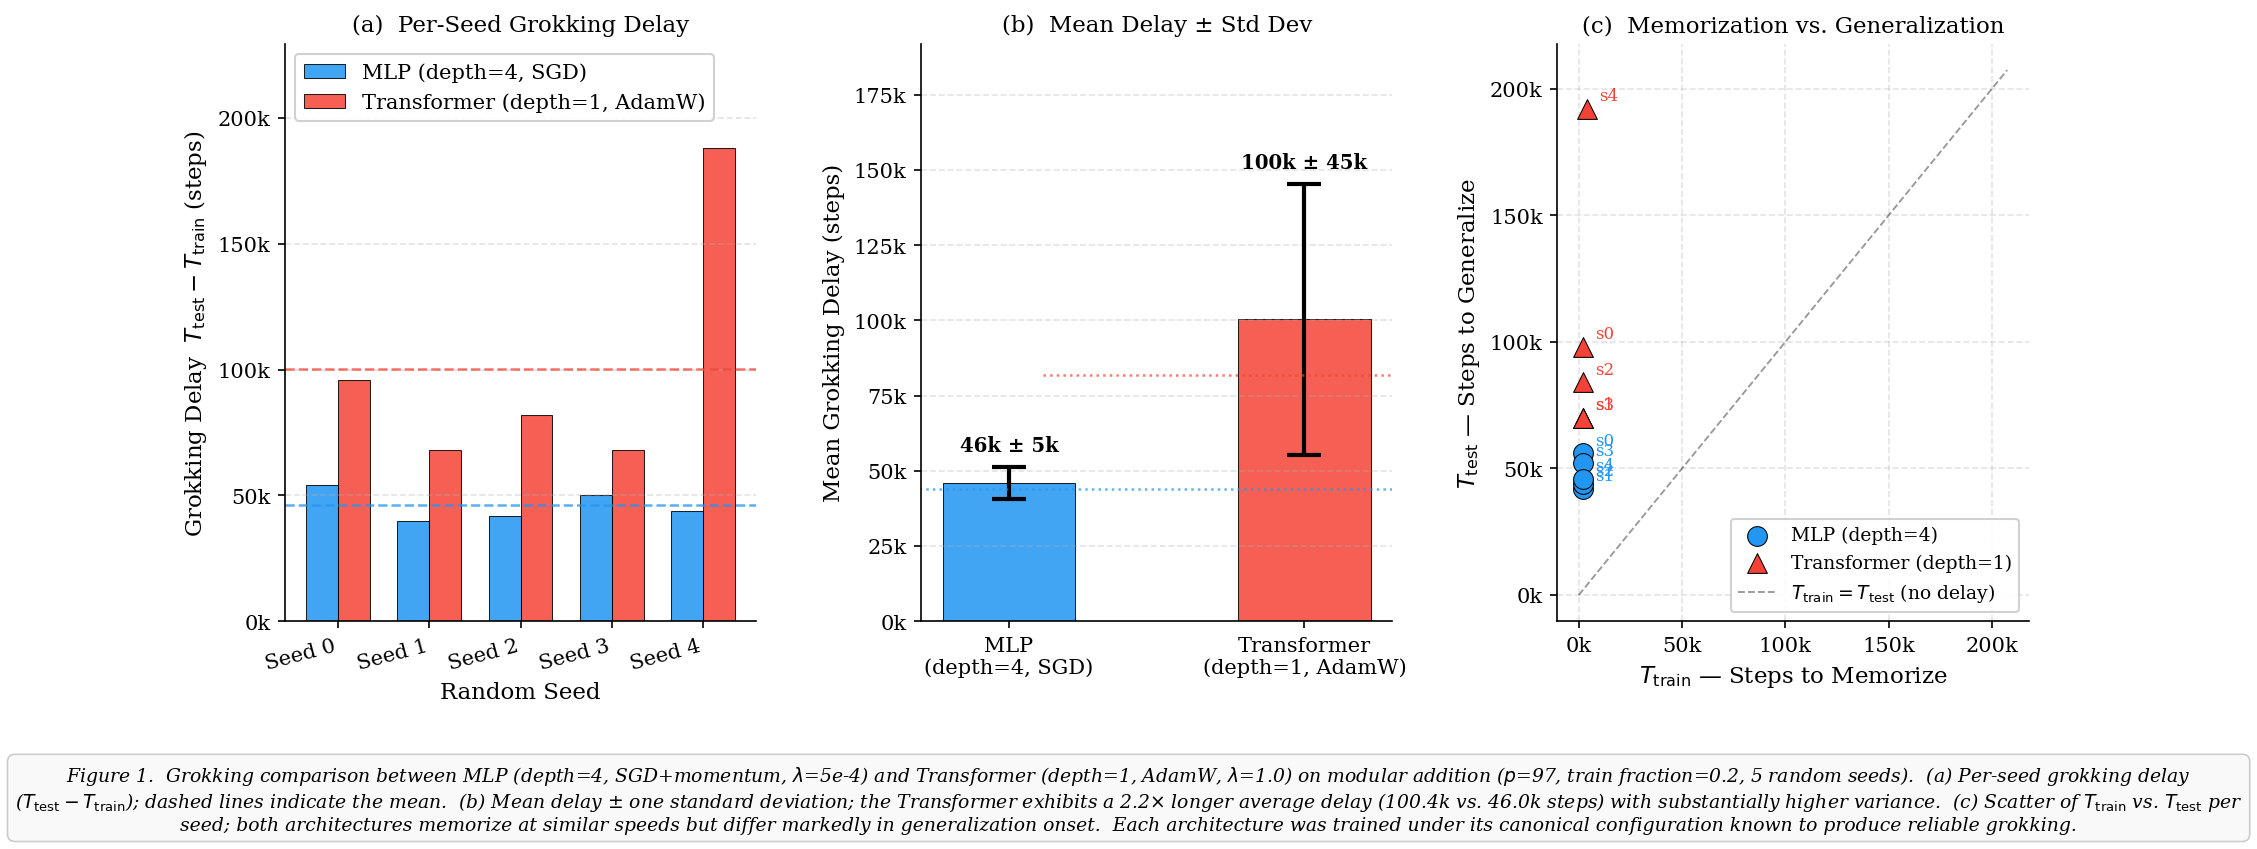

Saved: grokking_comparison.pdf  |  grokking_comparison.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ============================================================
# Results — directly from your experiment outputs
# ============================================================

mlp_results = {
    "T_train": [2000, 2000, 2000, 2000, 2000],
    "T_test":  [56000, 42000, 44000, 52000, 46000],
    "delay":   [54000, 40000, 42000, 50000, 44000],
}

transformer_results = {
    "T_train": [2000, 2000, 2000, 2000, 4000],
    "T_test":  [98000, 70000, 84000, 70000, 192000],
    "delay":   [96000, 68000, 82000, 68000, 188000],
}

seeds      = list(range(5))
MLP_COLOR  = "#2196F3"   # blue
TRF_COLOR  = "#F44336"   # red

mlp_delay   = mlp_results["delay"]
trf_delay   = transformer_results["delay"]
mlp_ttrain  = mlp_results["T_train"]
trf_ttrain  = transformer_results["T_train"]
mlp_ttest   = mlp_results["T_test"]
trf_ttest   = transformer_results["T_test"]

mlp_mean  = np.mean(mlp_delay)
trf_mean  = np.mean(trf_delay)
mlp_std   = np.std(mlp_delay)
trf_std   = np.std(trf_delay)
mlp_med   = np.median(mlp_delay)
trf_med   = np.median(trf_delay)

# ============================================================
# Styling
# ============================================================

plt.rcParams.update({
    "font.family":     "serif",
    "font.size":       11,
    "axes.titlesize":  11,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi":      150,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ============================================================
# Panel (a): Per-Seed Grokking Delay
# ============================================================

ax1 = fig.add_subplot(gs[0])
x     = np.arange(len(seeds))
width = 0.35

b1 = ax1.bar(x - width/2, mlp_delay, width,
             label="MLP (depth=4, SGD)",
             color=MLP_COLOR, alpha=0.85,
             edgecolor="black", linewidth=0.5)
b2 = ax1.bar(x + width/2, trf_delay, width,
             label="Transformer (depth=1, AdamW)",
             color=TRF_COLOR, alpha=0.85,
             edgecolor="black", linewidth=0.5)

ax1.axhline(mlp_mean, color=MLP_COLOR, linestyle="--",
            linewidth=1.2, alpha=0.75)
ax1.axhline(trf_mean, color=TRF_COLOR, linestyle="--",
            linewidth=1.2, alpha=0.75)

ax1.set_xlabel("Random Seed")
ax1.set_ylabel("Grokking Delay  $T_{\\mathrm{test}} - T_{\\mathrm{train}}$ (steps)")
ax1.set_title("(a)  Per-Seed Grokking Delay")
ax1.set_xticks(x)
ax1.set_xticklabels([f"Seed {s}" for s in seeds], rotation=15, ha="right")
ax1.legend(loc="upper left", framealpha=0.9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax1.set_ylim(0, max(trf_delay) * 1.22)
ax1.grid(axis="y", linestyle="--", alpha=0.35)

# ============================================================
# Panel (b): Mean Delay ± Std Dev
# ============================================================

ax2 = fig.add_subplot(gs[1])
archs  = ["MLP\n(depth=4, SGD)", "Transformer\n(depth=1, AdamW)"]
means  = [mlp_mean, trf_mean]
stds   = [mlp_std,  trf_std]
colors = [MLP_COLOR, TRF_COLOR]

bars = ax2.bar(archs, means, color=colors, alpha=0.85,
               edgecolor="black", linewidth=0.5, width=0.45)
ax2.errorbar(archs, means, yerr=stds, fmt="none",
             color="black", capsize=8, linewidth=2.0, capthick=2.0)

# annotate mean ± std
for bar, mean, std in zip(bars, means, stds):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 4000,
        f"{int(mean/1000)}k ± {int(std/1000)}k",
        ha="center", va="bottom",
        fontsize=9.5, fontweight="bold"
    )

# annotate median
for bar, med, color in zip(bars, [mlp_med, trf_med], colors):
    ax2.axhline(med, xmin=bar.get_x() / 3,
                color=color, linestyle=":",
                linewidth=1.2, alpha=0.7)

ax2.set_ylabel("Mean Grokking Delay (steps)")
ax2.set_title("(b)  Mean Delay ± Std Dev")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax2.set_ylim(0, (trf_mean + trf_std) * 1.32)
ax2.grid(axis="y", linestyle="--", alpha=0.35)

# ============================================================
# Panel (c): T_train vs T_test Scatter
# ============================================================

ax3 = fig.add_subplot(gs[2])

ax3.scatter(mlp_ttrain, mlp_ttest,
            color=MLP_COLOR, s=90, zorder=5,
            label="MLP (depth=4)", marker="o",
            edgecolors="black", linewidth=0.5)
ax3.scatter(trf_ttrain, trf_ttest,
            color=TRF_COLOR, s=90, zorder=5,
            label="Transformer (depth=1)", marker="^",
            edgecolors="black", linewidth=0.5)

for i, (tt, ttest) in enumerate(zip(mlp_ttrain, mlp_ttest)):
    ax3.annotate(f"s{i}", (tt, ttest),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=8, color=MLP_COLOR)
for i, (tt, ttest) in enumerate(zip(trf_ttrain, trf_ttest)):
    ax3.annotate(f"s{i}", (tt, ttest),
                 textcoords="offset points", xytext=(6, 4),
                 fontsize=8, color=TRF_COLOR)

lim_max = max(mlp_ttest + trf_ttest) * 1.08
ax3.plot([0, lim_max], [0, lim_max], "k--",
         linewidth=0.9, alpha=0.4,
         label="$T_{\\mathrm{train}} = T_{\\mathrm{test}}$ (no delay)")

ax3.set_xlabel("$T_{\\mathrm{train}}$ — Steps to Memorize")
ax3.set_ylabel("$T_{\\mathrm{test}}$ — Steps to Generalize")
ax3.set_title("(c)  Memorization vs. Generalization")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax3.legend(fontsize=9, framealpha=0.9)
ax3.grid(linestyle="--", alpha=0.35)

# ============================================================
# Figure caption (below figure)
# ============================================================

caption = (
    "Figure 1.  Grokking comparison between MLP (depth=4, SGD+momentum, $\\lambda$=5e-4) "
    "and Transformer (depth=1, AdamW, $\\lambda$=1.0) on modular addition ($p$=97, "
    "train fraction=0.2, 5 random seeds).  "
    "(a) Per-seed grokking delay ($T_{\\mathrm{test}} - T_{\\mathrm{train}}$); "
    "dashed lines indicate the mean.  "
    "(b) Mean delay $\\pm$ one standard deviation; the Transformer exhibits a "
    "2.2$\\times$ longer average delay (100.4k vs. 46.0k steps) with substantially "
    "higher variance.  "
    "(c) Scatter of $T_{\\mathrm{train}}$ vs. $T_{\\mathrm{test}}$ per seed; "
    "both architectures memorize at similar speeds but differ markedly in "
    "generalization onset.  Each architecture was trained under its canonical "
    "configuration known to produce reliable grokking."
)

fig.text(0.5, -0.08, caption, ha="center", va="top",
         fontsize=9, style="italic",
         wrap=True, transform=fig.transFigure,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f9",
                   edgecolor="#cccccc", linewidth=0.8))

# ============================================================
# Save
# ============================================================

plt.tight_layout()
plt.savefig("grokking_comparison.pdf", bbox_inches="tight")
plt.savefig("grokking_comparison.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved: grokking_comparison.pdf  |  grokking_comparison.png")